In [ ]:
import urllib.request
import zipfile
import os

if not os.path.exists("text8"):
    print("Downloading text8...")
    urllib.request.urlretrieve("http://mattmahoney.net/dc/text8.zip", "text8.zip")
    with zipfile.ZipFile("text8.zip") as f:
        f.extract("text8")
    print("Done.")

# Load and slice to 500k tokens (fast enough on Mac MPS)
with open("text8") as f:
    text = f.read()

words = text.split()[:500000]   # slice here — can be increased later if you want

chunk_size = 20
corpus = [" ".join(words[i:i+chunk_size])
          for i in range(0, len(words), chunk_size)]

def tokenize(text):
    return text.lower().split()

all_words = [w for sentence in corpus for w in tokenize(sentence)]
word_freq  = Counter(all_words)

# keeping only words that appear at least 5 times — kills noise
min_freq = 5
word_freq = {w: c for w, c in word_freq.items() if c >= min_freq}

vocab    = ['<PAD>', '<UNK>'] + sorted(word_freq.keys())
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
VOCAB_SIZE = len(vocab)

print(f"Using device: {device}")
print(f"Vocabulary Size: {VOCAB_SIZE}")
print(f"Total Tokens:    {len(all_words)}")

Using device: mps
Vocabulary Size: 8780
Total Tokens:    500000


In [32]:
def build_skipgram_pairs(corpus, word2idx, window_size = 2):
    pairs = []
    for sentence in corpus:
        tokens = tokenize(sentence)
        idxs = [word2idx.get(w, word2idx['<UNK>']) for w in tokens]
        for i, center in enumerate(idxs):
            left = max(0, i - window_size)
            right = min(len(idxs), i + window_size + 1)
            for j in range(left, right):
                if j != i :
                    pairs.append((center, idxs[j]))
    return pairs

pairs = build_skipgram_pairs(corpus, word2idx, window_size=2)
print(f"\nTotal skip-gram pairs: {len(pairs)}")

for center_idx, ctx_idx in pairs[:5]:
    print(f"  '{idx2word[center_idx]}' → '{idx2word[ctx_idx]}'")

class SkipGramDataset(Dataset):
    def __init__(self,pairs):
        self.pairs = pairs
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        center, context = self.pairs[idx]
        return torch.tensor(center), torch.tensor(context)

skipgram_dataset = SkipGramDataset(pairs)
dataloader = DataLoader(skipgram_dataset, batch_size = 64, shuffle= True)


Total skip-gram pairs: 1850000
  'anarchism' → 'originated'
  'anarchism' → 'as'
  'originated' → 'anarchism'
  'originated' → 'as'
  'originated' → 'a'


In [33]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embed_size):
        super().__init__()
        # Center word embeddings — these are what we care about
        self.center_embed  = nn.Embedding(vocab_size, embed_size)
        # Context word embeddings — separate matrix, discarded after training
        self.context_embed = nn.Embedding(vocab_size, embed_size)
        self._init_weights()

    def _init_weights(self):
        # Both tables start with tiny random values between -0.1 and 0.1
        nn.init.uniform_(self.center_embed.weight, -0.1, 0.1)
        nn.init.uniform_(self.context_embed.weight, -0.1, 0.1)

    def forward(self, center, context):
        # center:  (batch,)
        # context: (batch,)
        c_emb   = self.center_embed(center)     # (batch, embed_size)
        ctx_emb = self.context_embed(context)   # (batch, embed_size)
        # Dot product — high score = these words likely co-occur
        scores  = (c_emb * ctx_emb).sum(dim=1)  # (batch,)
        return scores

    def get_embeddings(self):
        """Return center embeddings as numpy array."""
        return self.center_embed.weight.detach().cpu().numpy()

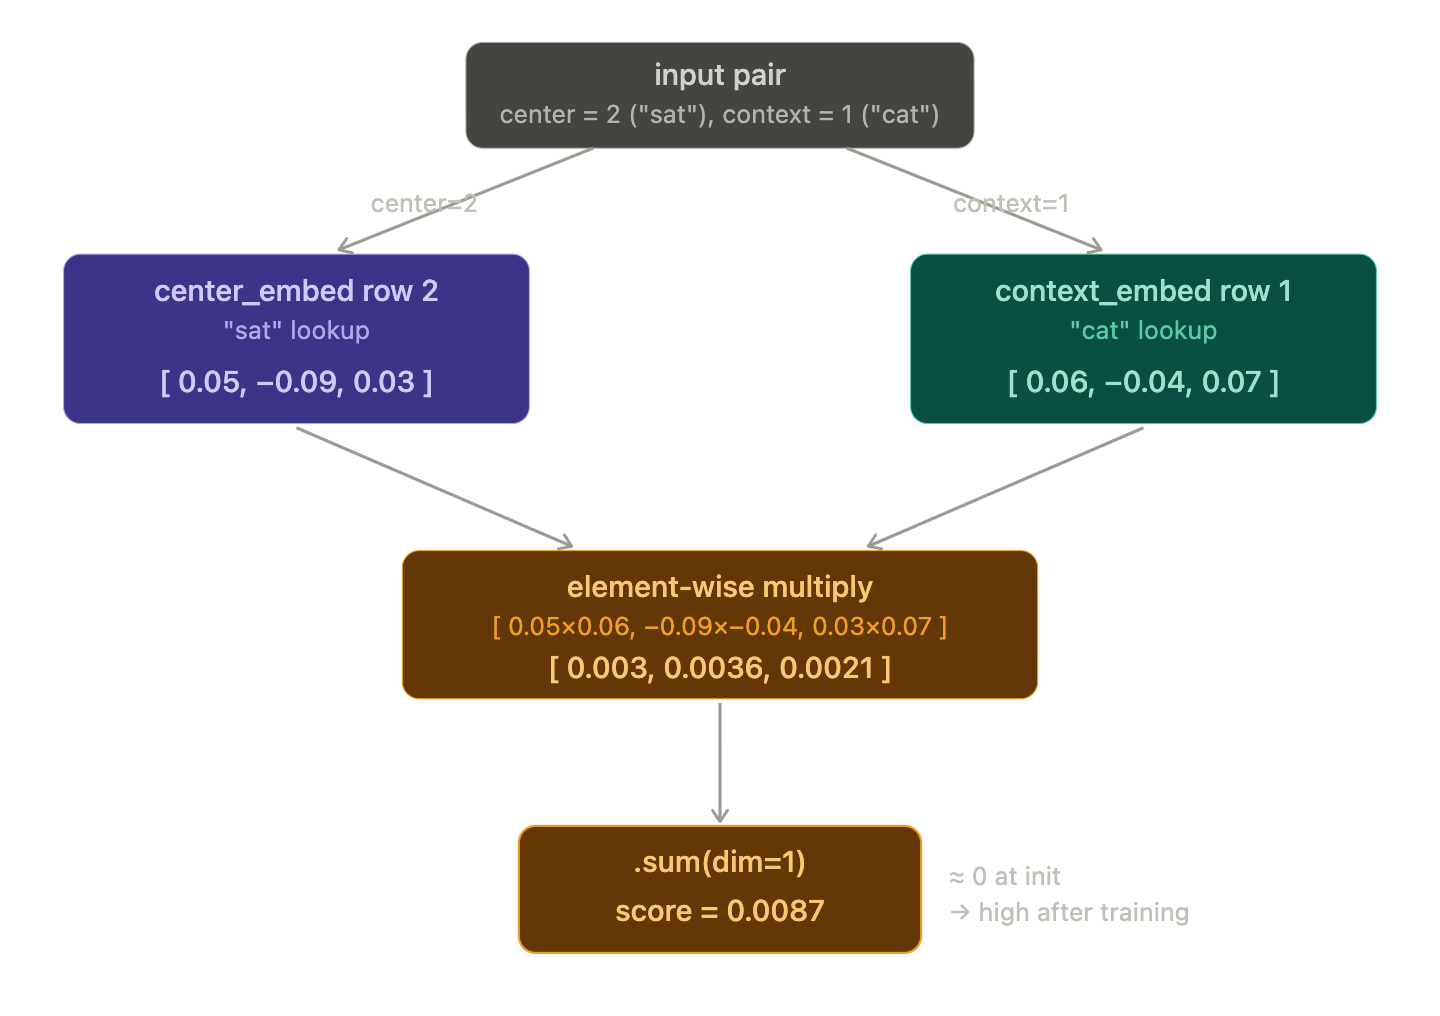

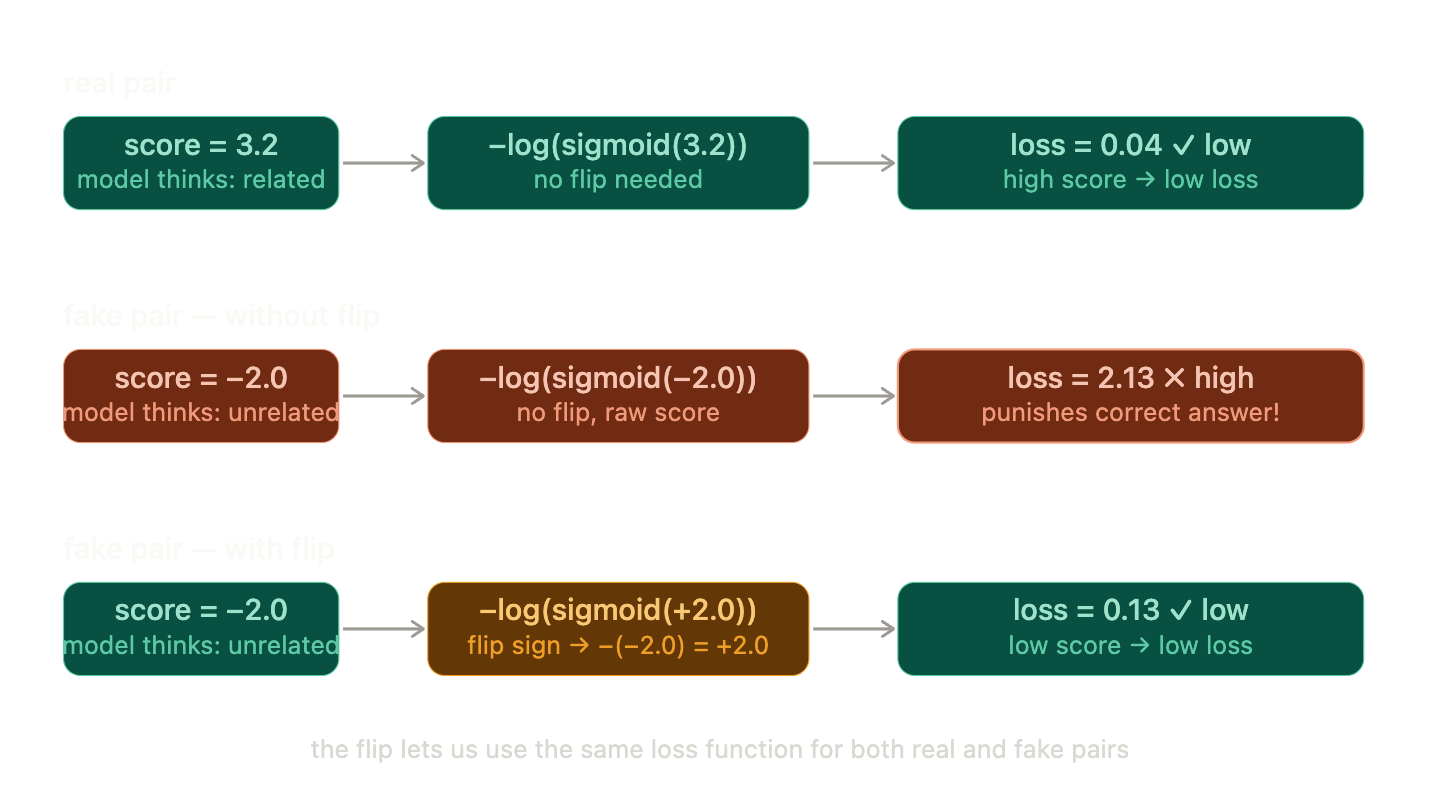

In [34]:
EMBED_SIZE   = 100
NEG_SAMPLES  = 5
EPOCHS       = 5
LR           = 0.001

model     = SkipGram(VOCAB_SIZE, EMBED_SIZE).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Negative sampling turns Word2Vec into a binary classifier. Real pair = 1, fake pair = 0.
# Where conventionally I used CrossEntropy or MSE here we are using negative sampling and calculating loss

def negative_sampling_loss(model, center, context, n_neg = 5):
    
    batch_size = center.shape[0]
    pos_score = model(center, context)
    pos_loss = F.logsigmoid(pos_score)

    neg_words = torch.randint(0, VOCAB_SIZE, (batch_size, n_neg)).to(device)
    neg_loss = torch.zeros(batch_size).to(device)

    for k in range(n_neg):
        neg_score = model(center, neg_words[:, k])
        neg_loss += F.logsigmoid(-neg_score)

    loss = -(pos_loss + neg_loss).mean()
    return loss 

print(f"\nTraining Skip-gram with Negative Sampling...")
train_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0
    model.train()

    for center_batch, ctx_batch in dataloader:
        center_batch = center_batch.to(device)
        ctx_batch    = ctx_batch.to(device)

        optimizer.zero_grad()
        loss = negative_sampling_loss(model, center_batch, ctx_batch, NEG_SAMPLES)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"  Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f}")

def most_similar(word, topn=5):
    if word not in word2idx:
        print(f"'{word}' not in vocab")
        return
    
    embeddings = torch.tensor(model.get_embeddings())
    idx = word2idx[word]
    vec = embeddings[idx]
    
    # cosine similarity against all words
    sims = F.cosine_similarity(vec.unsqueeze(0), embeddings)
    sims[idx] = -1  # exclude the word itself
    top_indices = sims.topk(topn).indices.tolist()
    
    print(f"\nMost similar to '{word}':")
    for i in top_indices:
        print(f"  {idx2word[i]:<15} {sims[i].item():.3f}")

most_similar("king")
most_similar("computer")
most_similar("river")


Training Skip-gram with Negative Sampling...
  Epoch 01/5 | Loss: 1.5206
  Epoch 02/5 | Loss: 1.3155
  Epoch 03/5 | Loss: 1.2307
  Epoch 04/5 | Loss: 1.1722
  Epoch 05/5 | Loss: 1.1299

Most similar to 'king':
  afghana         0.516
  und             0.455
  solomon         0.445
  son             0.441
  viii            0.437

Most similar to 'computer':
  desktop         0.570
  apple           0.565
  macintosh       0.530
  consumer        0.522
  mac             0.517

Most similar to 'river':
  cuanza          0.515
  cunene          0.484
  valley          0.482
  mississippi     0.478
  delaware        0.460


In [36]:
def get_embedding(word):
    idx = word2idx.get(word, word2idx['<UNK>'])
    return model.center_embed(
        torch.tensor(idx).to(device)
    ).detach().cpu().numpy()

def cosine_similarity(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)

def most_similar(word, topn=5):
    """Find most similar words by cosine similarity."""
    if word not in word2idx:
        return []
    target  = get_embedding(word)
    all_emb = model.get_embeddings()
    sims    = []
    for idx, emb in enumerate(all_emb):
        w = idx2word[idx]
        if w in ['<PAD>', '<UNK>', word]:
            continue
        sims.append((w, cosine_similarity(target, emb)))
    return sorted(sims, key=lambda x: x[1], reverse=True)[:topn]

def word_analogy(word_a, word_b, word_c):
    """
    word_a is to word_b as word_c is to ?
    Classic: king - man + woman = queen
    vector(b) - vector(a) + vector(c) → find nearest
    """
    emb_a = get_embedding(word_a)
    emb_b = get_embedding(word_b)
    emb_c = get_embedding(word_c)
    target = emb_b - emb_a + emb_c

    all_emb = model.get_embeddings()
    sims = []
    exclude = {word_a, word_b, word_c, '<PAD>', '<UNK>'}
    for idx, emb in enumerate(all_emb):
        w = idx2word[idx]
        if w in exclude:
            continue
        sims.append((w, cosine_similarity(target, emb)))
    return sorted(sims, key=lambda x: x[1], reverse=True)[:3]

print("\n── Similarity Tests ────────────────────────────────")
test_words = ['king', 'cat', 'computer', 'mountain']
for word in test_words:
    if word in word2idx:
        similar = most_similar(word, topn=3)
        sim_str = ', '.join([f"{w}({s:.2f})" for w, s in similar])
        print(f"  '{word}' → {sim_str}")

print("\n── Analogy Tests ───────────────────────────────────")
# These won't be perfect on a tiny corpus but directionally interesting
analogies = [
    ('king', 'queen', 'prince'),
    ('paris', 'france', 'london'),    # paris:france :: london:?  → england
    ('man', 'woman', 'king'),         # the classic
]
for a, b, c in analogies:
    if all(w in word2idx for w in [a, b, c]):
        result = word_analogy(a, b, c)
        print(f"  '{a}' - '{b}' + '{c}' = {[(w, f'{s:.2f}') for w, s in result]}")


── Similarity Tests ────────────────────────────────
  'king' → afghana(0.52), und(0.46), solomon(0.44)
  'cat' → vocals(0.56), bckgr(0.52), chris(0.51)
  'computer' → desktop(0.57), apple(0.56), macintosh(0.53)
  'mountain' → hayastan(0.51), latitudes(0.47), coral(0.47)

── Analogy Tests ───────────────────────────────────
  'king' - 'queen' + 'prince' = [('anchor', '0.43'), ('joan', '0.42'), ('radcliffe', '0.41')]
  'paris' - 'france' + 'london' = [('carolina', '0.40'), ('germany', '0.39'), ('isbn', '0.38')]
  'man' - 'woman' + 'king' = [('son', '0.43'), ('hemispheres', '0.38'), ('priam', '0.38')]


^^ since i ran it on just 500k datapoints and 5 epochs, the connections are half built and one thing to notice here is, cat is a RARE word in wikpedia hence the wrong realtion emerging there.

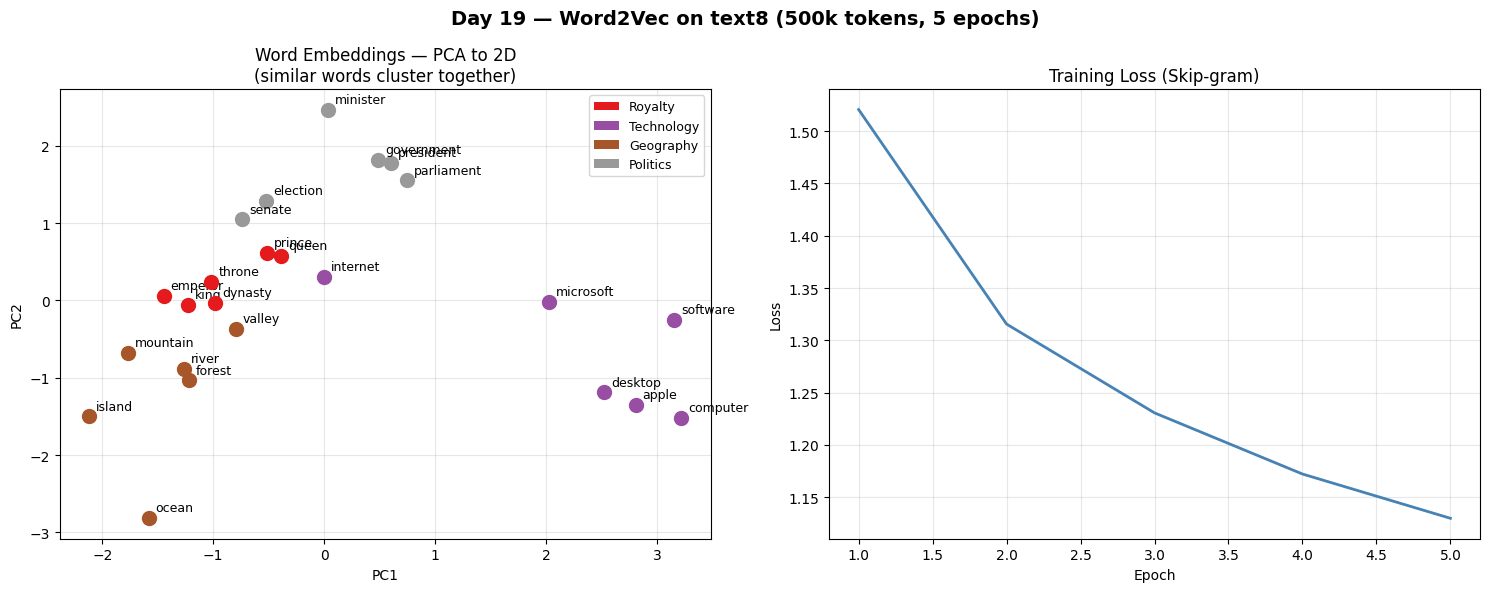

In [38]:
def pca_2d(embeddings):
    """Manual PCA — center then project onto top 2 principal components."""
    emb     = embeddings - embeddings.mean(axis=0)
    cov     = np.cov(emb.T)
    vals, vecs = np.linalg.eig(cov)
    # Sort by eigenvalue descending
    order   = np.argsort(vals)[::-1]
    top2    = vecs[:, order[:2]].real
    return emb @ top2

# Words to visualize — pick themed groups
viz_words = {
    'Royalty':    ['king', 'queen', 'prince', 'emperor', 'dynasty', 'throne'],
    'Technology': ['computer', 'software', 'internet', 'apple', 'microsoft', 'desktop'],
    'Geography':  ['mountain', 'river', 'valley', 'ocean', 'island', 'forest'],
    'Politics':   ['president', 'government', 'parliament', 'minister', 'election', 'senate'],
}

all_viz_words = [w for group in viz_words.values() for w in group
                 if w in word2idx]
all_emb_viz   = np.array([get_embedding(w) for w in all_viz_words])
coords_2d     = pca_2d(all_emb_viz)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Day 19 — Word2Vec on text8 (500k tokens, 5 epochs)', fontsize=14, fontweight='bold')

# PCA plot
colors = cm.Set1(np.linspace(0, 1, len(viz_words)))
color_map = {}
idx_counter = 0
group_colors = {}
for (group, words), color in zip(viz_words.items(), colors):
    group_colors[group] = color
    for w in words:
        if w in word2idx:
            color_map[w] = color

for i, word in enumerate(all_viz_words):
    x, y = coords_2d[i]
    axes[0].scatter(x, y, color=color_map[word], s=100, zorder=3)
    axes[0].annotate(word, (x, y),
                     textcoords="offset points", xytext=(5, 5),
                     fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=g)
                   for g, c in group_colors.items()]
axes[0].legend(handles=legend_elements, loc='best', fontsize=9)
axes[0].set_title('Word Embeddings — PCA to 2D\n(similar words cluster together)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].grid(True, alpha=0.3)

# Training loss
axes[1].plot(range(1, EPOCHS+1), train_losses,
             color='steelblue', linewidth=2)
axes[1].set_title('Training Loss (Skip-gram)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
